In [2]:
import math,re,os,sys
import matplotlib
import GRIDINFORMER
%matplotlib inline
import netCDF4 as NC


from matplotlib import pyplot as PLT

from   GRIDINFORMER import MATH_TOOLS as MTOOL
from   GRIDINFORMER import TOOLS 

In [3]:
import importlib

from GRIDINFORMER import TOOLS
from GRIDINFORMER import MATH_TOOLS 
NearestNeighbor = MATH_TOOLS.NearestNeighbor

In [4]:
from mpl_toolkits import basemap
import wrf

In [5]:
from wrf import getvar

In [6]:
NearestNeighbor2 = MATH_TOOLS.NearestNeighbor_limited

In [7]:
def get_d02_latlon(WRF_D02):
    numNY = WRF_D02.dimensions["south_north"].size
    numNX = WRF_D02.dimensions["west_east"].size
    arrCLAT = WRF_D02.variables["CLAT"][0]
    arrCLON = WRF_D02.variables["CLONG"][0]
    
    arrCoords = [   ]

    # SW - SE
    for indx in range(0, numNX, 10):
        numInX = indx
        numInY = 0
        arrCoords.append([ arrCLON[numInY][numInX],
                           arrCLAT[numInY][numInX] ])
    # SE - NE
    for indy in range(0, numNY, 10):
        numInX = numNX - 1
        numInY = indy
        arrCoords.append([ arrCLON[numInY][numInX],
                           arrCLAT[numInY][numInX] ])

    # NE - NW
    for indx in range(numNX-1, 0, -10):
        numInX = indx
        numInY = numNY-1
        arrCoords.append([ arrCLON[numInY][numInX],
                           arrCLAT[numInY][numInX] ])
    # NW - SW
    for indy in range(numNY-1, 0, -10):
        numInX = 0
        numInY = indy
        arrCoords.append([ arrCLON[numInY][numInX],
                           arrCLAT[numInY][numInX] ])
    # [LON, LAT]
    return arrCoords
    print(arrCoords)


    
def get_d02_latlon_in_map(map, arrCoordsIn):
    
    numArrSize = len(arrCoordsIn)
    arrOut     = [ [] for n in range(numArrSize) ]
    
    for ind_n in range(numArrSize):
        arrMap    = map(arrCoordsIn[ind_n][0], arrCoordsIn[ind_n][1])
        arrOut[ind_n] = [ arrMap[0], arrMap[1] ]
    return arrOut
    

In [8]:
def Find_Xest(arrIn, dim_x, dim_y, num_crop=20, numMax = 9E20):
    numMinOut    =  numMax
    numMaxOut    = -1 * numMax
    Min_i       = 0
    Min_j       = 0
    Max_i       = 0
    Max_j       = 0
    MinV        = 0
    MaxV        = 0
    for j in range(num_crop, dim_y-num_crop):
        for i in range(num_crop, dim_x-num_crop):
            numIn      =  arrIn[j][i]
            numMinOut =  min( numMinOut, numIn )
            numMaxOut =  max( numMaxOut, numIn )
            if numIn == numMinOut:
                MinV   = numIn
                Min_i = i
                Min_j = j
            if numIn == numMaxOut:
                MaxV   = numIn
                Max_i = i
                Max_j = j
    dicOut = {"MinV": MinV, "MinJ": Min_j, "MinI": Min_i,\
              "MaxV": MaxV, "MaxJ": Max_j, "MaxI": Max_i}
    return dicOut


Preparing to plot
T: 58 [2015, 8, 6] [0, 0, 0]
Center of Typhoon, lat, lon:  130.2 20.45
Design retangle grids as radius :  40
i_parent, j_parent: 131, 148


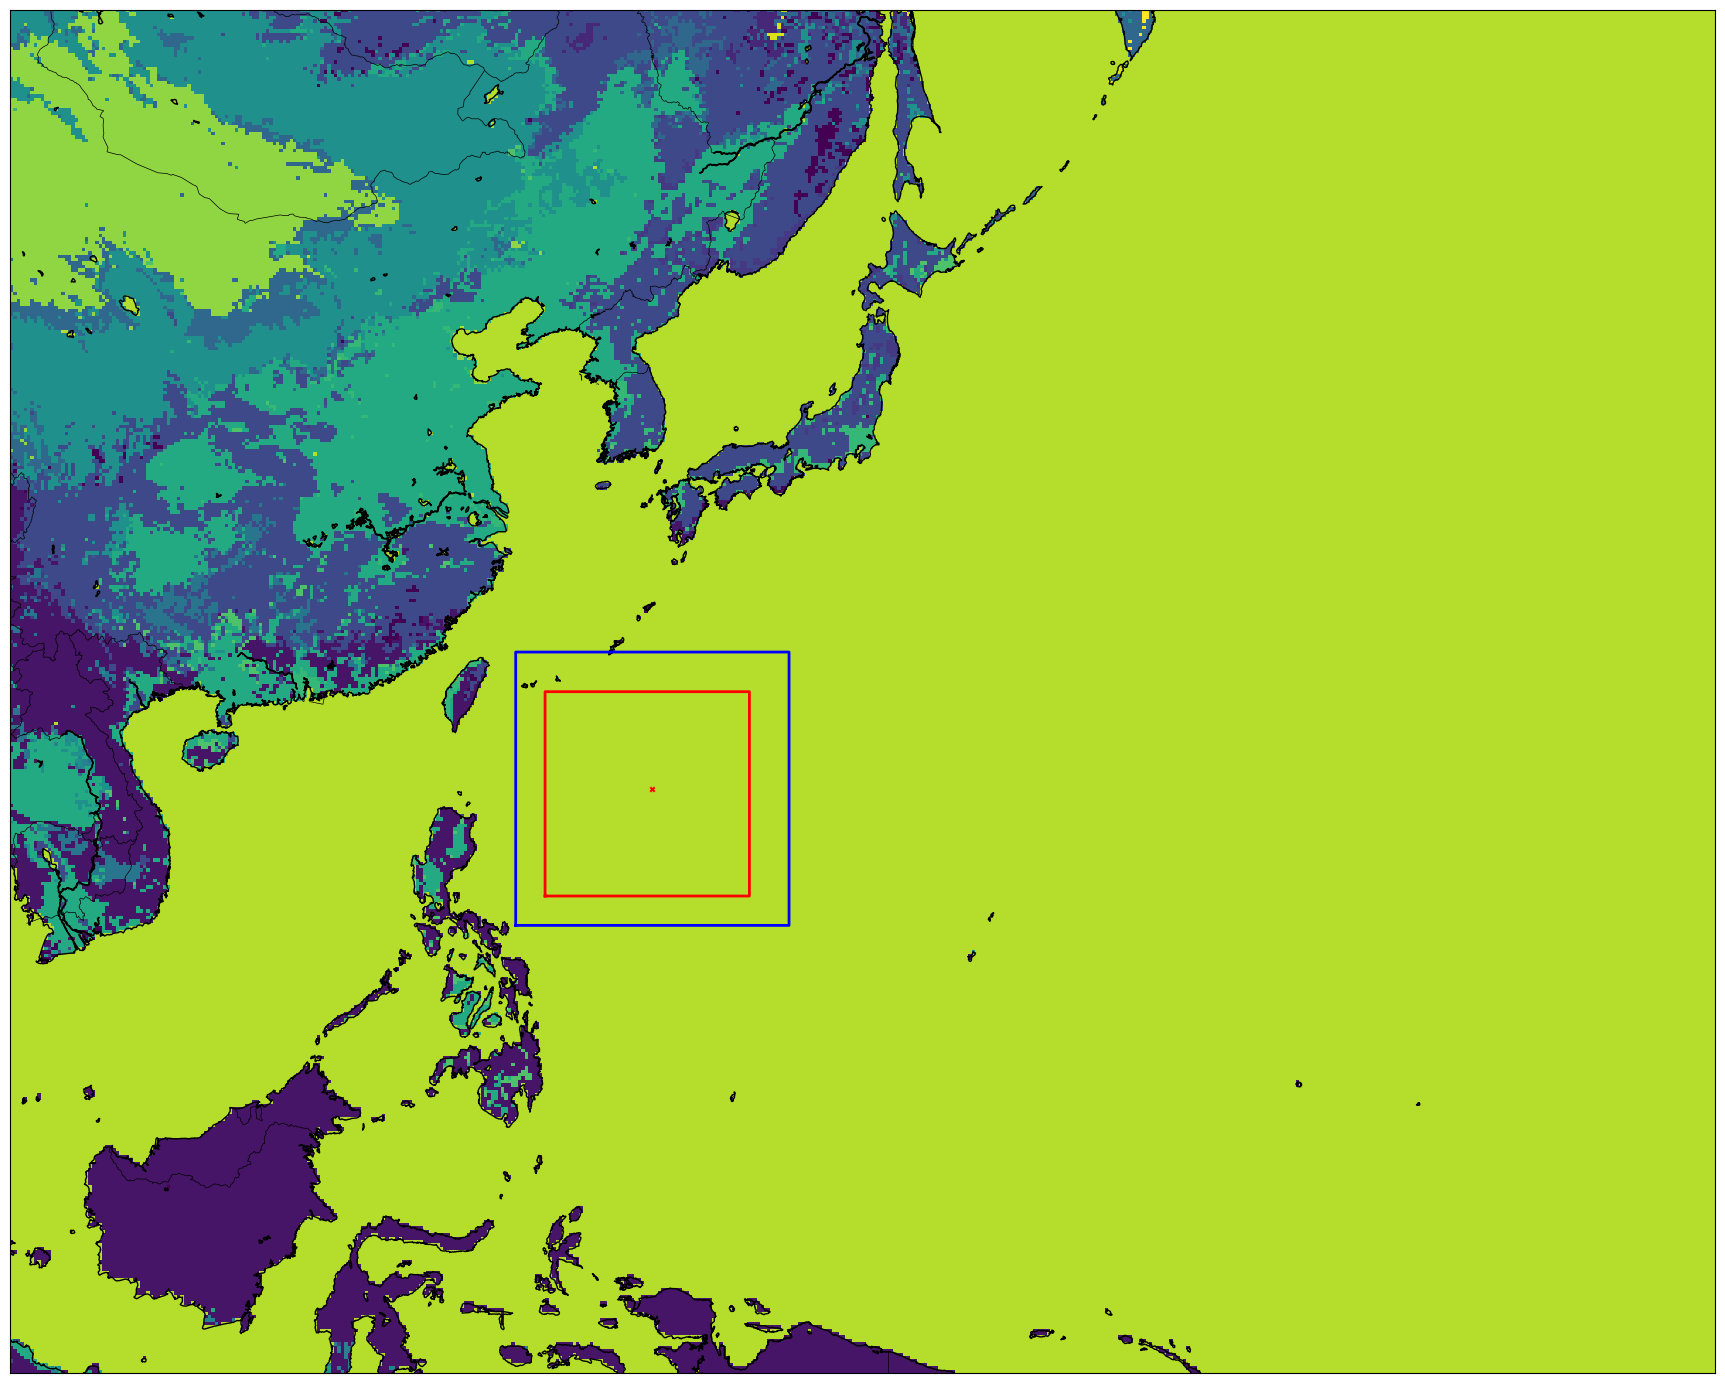

In [9]:
#NC_DATA_WRF_D01.close()
#NC_DATA_WRF_D02.close()

dirWPS = "/p/data1/slmet/model_data/wrf/TC_Soudelor/wrfin"

#NC_DATA_WRF.close()
NC_DATA_WRF_D01a   = NC.Dataset("{0:s}/geo_em.d01.nc".format(dirWPS), "r")
NC_DATA_WRF_D02a   = NC.Dataset("{0:s}/geo_em.d02.nc".format(dirWPS), "r")

DR = GRIDINFORMER.DATA_READER()
DIC_OUT = DR.IbtracsReader("/p/scratch/exaww/lu3/WRFV4/WRF_MND/IBTRACS.Soudelor.dat")

SW_Lat = NC_DATA_WRF_D02a.variables["CLAT"][0][0][0]
SW_Lon = NC_DATA_WRF_D02a.variables["CLONG"][0][0][0]

NW_Lat = NC_DATA_WRF_D02a.variables["CLAT"][0][-1][0]
NW_Lon = NC_DATA_WRF_D02a.variables["CLONG"][0][-1][0]

SE_Lat = NC_DATA_WRF_D02a.variables["CLAT"][0][0][-1]
SE_Lon = NC_DATA_WRF_D02a.variables["CLONG"][0][0][-1]

NE_Lat = NC_DATA_WRF_D02a.variables["CLAT"][0][-1][-1]
NE_Lon = NC_DATA_WRF_D02a.variables["CLONG"][0][-1][-1]

print("Preparing to plot")

FIG = PLT.figure(figsize=(22,20))
map = basemap.Basemap(
                      projection="lcc",
                      llcrnrlon=NC_DATA_WRF_D01a.variables["CLONG"][0][0][0],
                      llcrnrlat=NC_DATA_WRF_D01a.variables["CLAT"] [0][0][0],
                      urcrnrlon=NC_DATA_WRF_D01a.variables["CLONG"][0][-1][-1],
                      urcrnrlat=NC_DATA_WRF_D01a.variables["CLAT"] [0][-1][-1],
                      lat_0=NC_DATA_WRF_D01a.CEN_LAT,
                      lon_0=NC_DATA_WRF_D01a.STAND_LON,
                      lat_1=NC_DATA_WRF_D01a.TRUELAT1,
                      lat_2=NC_DATA_WRF_D01a.TRUELAT2,
                      resolution='i')

                      #llcrnrlon=NC_DATA_WRF.variables["CLONG"][0][0][0],
                      #llcrnrlat=NC_DATA_WRF.variables["CLAT"] [0][0][0],
                      #urcrnrlon=NC_DATA_WRF.variables["CLONG"][0][-1][-1],
                      #urcrnrlat=NC_DATA_WRF.variables["CLAT"] [0][-1][-1],

                                                                  
AX = FIG.add_subplot(111)

map.imshow(NC_DATA_WRF_D01a.variables['LU_INDEX'][0])
map.drawcoastlines()
map.drawcountries()

SW_map = map(SW_Lon,SW_Lat) 
NW_map = map(NW_Lon,NW_Lat)
SE_map = map(SE_Lon,SE_Lat)
NE_map = map(NE_Lon,NE_Lat)

map.plot([SW_map[0], NW_map[0], NE_map[0], SE_map[0], SW_map[0]],\
         [SW_map[1], NW_map[1], NE_map[1], SE_map[1], SW_map[1]],\
          "r-",lw=2.0)    

ind_t = 58
num_target_x = DIC_OUT["LON"][ind_t]
num_target_y = DIC_OUT["LAT"][ind_t]
print("T:", ind_t, DIC_OUT["DATE"][ind_t], DIC_OUT["TIME"][ind_t])
print("Center of Typhoon, lat, lon: ",num_target_x, num_target_y)

num_target_x = DIC_OUT["LON"][ind_t]
num_target_y = DIC_OUT["LAT"][ind_t]
arrLON = NC_DATA_WRF_D01a.variables["CLONG"][0]
arrLAT = NC_DATA_WRF_D01a.variables["CLAT"][0]
found_i, found_j = NearestNeighbor(arrLON, arrLAT, num_target_x, num_target_y)

num_tc_center_i, num_tc_center_j = map(arrLON[found_j][found_i], arrLAT[found_j][found_i])

Radius_nx = int(200 * 3 / 15)
print("Design retangle grids as radius : ", Radius_nx)

SW_ideal = map(NC_DATA_WRF_D01a.variables["CLONG"][0][found_j-Radius_nx][found_i-Radius_nx],
               NC_DATA_WRF_D01a.variables["CLAT"][0][found_j-Radius_nx][found_i-Radius_nx]) 
NW_ideal = map(NC_DATA_WRF_D01a.variables["CLONG"][0][found_j+Radius_nx][found_i-Radius_nx],
               NC_DATA_WRF_D01a.variables["CLAT"][0][found_j+Radius_nx][found_i-Radius_nx]) 
SE_ideal = map(NC_DATA_WRF_D01a.variables["CLONG"][0][found_j-Radius_nx][found_i+Radius_nx],
               NC_DATA_WRF_D01a.variables["CLAT"][0][found_j-Radius_nx][found_i+Radius_nx]) 
NE_ideal = map(NC_DATA_WRF_D01a.variables["CLONG"][0][found_j+Radius_nx][found_i+Radius_nx],
               NC_DATA_WRF_D01a.variables["CLAT"][0][found_j+Radius_nx][found_i+Radius_nx]) 
map.plot([SW_ideal[0], NW_ideal[0], NE_ideal[0], SE_ideal[0], SW_ideal[0]],\
         [SW_ideal[1], NW_ideal[1], NE_ideal[1], SE_ideal[1], SW_ideal[1]],\
          "b-",lw=2.0) 

print("i_parent, j_parent: {0:d}, {1:d}".format(found_j-Radius_nx, found_i-Radius_nx))

map.scatter(num_tc_center_i, num_tc_center_j, 10.0, c="red", marker="x" )

In [12]:
# Try to find the center of the D02 in the IBTRacT

DR = GRIDINFORMER.DATA_READER()
DIC_OUT = DR.IbtracsReader("/p/scratch/exaww/lu3/WRFV4/WRF_MND/IBTRACS.Soudelor.dat")


In [11]:
ind_t = 58
print("T:", ind_t, DIC_OUT["DATE"][ind_t], DIC_OUT["TIME"][ind_t])
num_target_x = DIC_OUT["LON"][ind_t]
num_target_y = DIC_OUT["LAT"][ind_t]
arrLON = NC_DATA_WRF_D01a.variables["CLONG"][0]
arrLAT = NC_DATA_WRF_D01a.variables["CLAT"][0]
found_i, found_j = NearestNeighbor(arrLON, arrLAT, num_target_x, num_target_y)
#arrJI[T] =  found_i, found_j 
#    TOOLS.progress_bar((T)/float(numT-1))
print(found_i, found_j)
DX = 15
NX = 300/15 # How many grid, for 300 KM radius
arrIParentSta = int(found_i - NX)
arrJParentSta = int(found_j - NX)
print("Parent I: {0:d}".format(arrIParentSta))
print("Parent J: {0:d}".format(arrJParentSta))

T: 58 [2015, 8, 6] [0, 0, 0]
188 171
Parent I: 168
Parent J: 151


## Check the Geogrid files from WRFV4

## Tracing the track of TC

In [16]:
arrLAT        = NC_DATA_WRF5D01.variables["CLAT"][0]
arrLON        = NC_DATA_WRF5D01.variables["CLONG"][0]

In [17]:
numT = len(DIC_OUT["LON"])
arrJI = [ [0,0] for T in range(numT) ]
for T in range(numT):
    num_target_x = DIC_OUT["LON"][T]
    num_target_y = DIC_OUT["LAT"][T]
    found_i, found_j = NearestNeighbor(arrLON, arrLAT, num_target_x, num_target_y)
    arrJI[T] = [ found_i, found_j ]
    TOOLS.progress_bar((T)/float(numT-1))

[====================] 100.00% Progress

In [18]:
arr_moving = [ [0,0] for T in range(numT)]
last_arr = [ arrJI[0][0] , arrJI[0][1]   ] 
for T in range(1,numT):
    diffX = ( arrJI[T][0] - last_arr[0] ) * 3000
    diffY = ( arrJI[T][1] - last_arr[1] ) * 3000
    arr_moving[T] = [ diffX, diffY ] 
    last_arr = [ arrJI[T][0] , arrJI[T][1] ]   

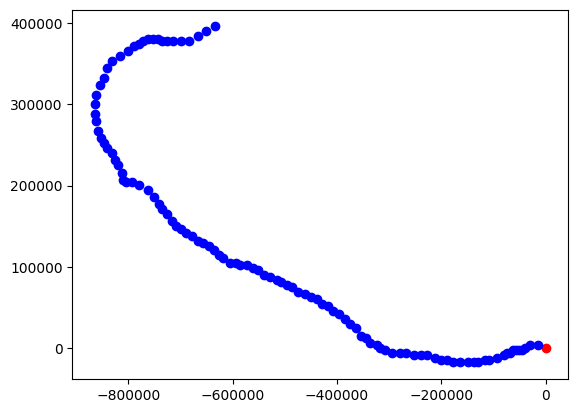

In [19]:
PLT.plot(arr_moving[0][0], arr_moving[0][1], 'ro')
arrLast = [ arr_moving[0][0], arr_moving[0][1] ] 
for T in range(1,numT):
    PLT.plot(arrLast[0] + arr_moving[T][0], arrLast[1] + arr_moving[T][1], 'bo')
    arrLast = [ arrLast[0] + arr_moving[T][0], arrLast[1] + arr_moving[T][1] ] 

In [21]:
LAT_IN        = NC_DATA_WRF5D01.variables["CLAT"][0]
LON_IN        = NC_DATA_WRF5D01.variables["CLONG"][0]
lenNY  = len(LON_IN)
lenNX  = len(LON_IN[0])

arr_numDist = []

T=0
numTargetLat = DIC_OUT["LAT"][T]
numTargetLon = DIC_OUT["LON"][T]
numDist_chk  = 9999999
for j in range(lenNY - 1):
    for i in range(lenNX - 1):
        chk1    = (LAT_IN[j][i]   - numTargetLat) ** 2
        chk3    = (LON_IN[j][i]   - numTargetLon) ** 2
        numDist = (chk1 + chk3 ) ** 0.5
        arr_numDist.append(numDist)
        if min(numDist_chk, numDist) == numDist:
            numDist_chk = numDist
            #print(numDist)
            found_i = i
            found_j = j
        
#print(found_i, found_j)        

In [22]:
lenNY  = len(LON_IN)
lenNX  = len(LON_IN[0])

arr_numDist = []

T=0
numTargetLat = DIC_OUT["LAT"][T]
numTargetLon = DIC_OUT["LON"][T]
numDist_chk  = 9999999
for j in range(lenNY - 1):
    for i in range(lenNX - 1):
        chk1    = (LAT_IN[j][i]   - numTargetLat) ** 2
        chk3    = (LON_IN[j][i]   - numTargetLon) ** 2
        numDist = (chk1 + chk3 ) ** 0.5
        arr_numDist.append(numDist)
        if min(numDist_chk, numDist) == numDist:
            numDist_chk = numDist
            #print(numDist)
            found_i = i
            found_j = j
        
#print(found_i, found_j)        

In [23]:
print("{0:5s}, {1:15s} | {2:6s} | {3:5s} | {4:7s} | {5:7s} ".format("T", "TIMESTEP", "LON", "LAT", "DIST-E", "DIST-N"))
for T in range(numT):
    arrD = DIC_OUT["DATE"][T]
    arrT = DIC_OUT["TIME"][T]
    DATETIME = "{0:04d}-{1:02d}-{2:02d}_{3:02d}".format(arrD[0], arrD[1], arrD[2], arrT[0])
    print("{0:4d} , {1:15s} | {2:5.2f} , {3:5.2f} , {4:7d} , {5:7d} , {6:7d} , {7:7d}  "
          .format( T, DATETIME, DIC_OUT["LON"][T], DIC_OUT["LAT"][T], arr_moving[T][0], arr_moving[T][1],
                                                                             arrJI[T][0] - arrJI[T-1][0], 
                                                                             arrJI[T][1] - arrJI[T-1][1]))

T    , TIMESTEP        | LON    | LAT   | DIST-E  | DIST-N  
   0 , 2015-07-29_18   | 162.20 , 13.30 ,       0 ,       0 ,     211 ,    -132  
   1 , 2015-07-29_21   | 161.40 , 13.55 ,  -15000 ,    3000 ,      -5 ,       1  
   2 , 2015-07-30_00   | 160.72 , 13.68 ,  -15000 ,       0 ,      -5 ,       0  
   3 , 2015-07-30_03   | 160.26 , 13.64 ,   -9000 ,   -3000 ,      -3 ,      -1  
   4 , 2015-07-30_06   | 159.89 , 13.60 ,   -6000 ,   -3000 ,      -2 ,      -1  
   5 , 2015-07-30_09   | 159.57 , 13.61 ,   -6000 ,       0 ,      -2 ,       0  
   6 , 2015-07-30_12   | 159.28 , 13.63 ,   -6000 ,       0 ,      -2 ,       0  
   7 , 2015-07-30_15   | 159.02 , 13.61 ,   -6000 ,       0 ,      -2 ,       0  
   8 , 2015-07-30_18   | 158.75 , 13.57 ,   -6000 ,   -3000 ,      -2 ,      -1  
   9 , 2015-07-30_21   | 158.46 , 13.53 ,   -6000 ,       0 ,      -2 ,       0  
  10 , 2015-07-31_00   | 158.05 , 13.48 ,   -6000 ,   -3000 ,      -2 ,      -1  
  11 , 2015-07-31_03   | 157.44 , 13.

In [24]:
print("{0:5s}, {1:15s} | {2:6s} | {3:5s} | {4:7s} | {5:7s} | {6:6s} | {7:6s} | {8:6s} | {9:6s}  "
                       .format("   T", "    TIMESTEP", "   LON", "  LAT", " DIST-E", " DIST-N", "     I", "     J", "Dist_I", "Dist_J"))
for T in range(2, numT, 2):
    arrD = DIC_OUT["DATE"][T]
    arrT = DIC_OUT["TIME"][T]
    DATETIME = "{0:04d}-{1:02d}-{2:02d}_{3:02d}".format(arrD[0], arrD[1], arrD[2], arrT[0])
    print("{0:4d} , {1:15s} | {2:5.2f} , {3:5.2f} , {4:7d} , {5:7d} , {6:6d} , {7:6d} , {8:6d} , {9:6d} "
          .format( int(T/2), DATETIME, DIC_OUT["LON"][T], DIC_OUT["LAT"][T], arr_moving[T][0] + arr_moving[T-1][0],\
                                                                             arr_moving[T][1] + arr_moving[T-1][1],\
                                                                             arrJI[T][0], arrJI[T][1],
                                                                             arrJI[T][0] - arrJI[T-1][0], 
                                                                             arrJI[T][1] - arrJI[T-1][1]))

   T ,     TIMESTEP    |    LON |   LAT |  DIST-E |  DIST-N |      I |      J | Dist_I | Dist_J  
   1 , 2015-07-30_00   | 160.72 , 13.68 ,  -30000 ,    3000 ,    387 ,    134 ,     -5 ,      0 
   2 , 2015-07-30_06   | 159.89 , 13.60 ,  -15000 ,   -6000 ,    382 ,    132 ,     -2 ,     -1 
   3 , 2015-07-30_12   | 159.28 , 13.63 ,  -12000 ,       0 ,    378 ,    132 ,     -2 ,      0 
   4 , 2015-07-30_18   | 158.75 , 13.57 ,  -12000 ,   -3000 ,    374 ,    131 ,     -2 ,     -1 
   5 , 2015-07-31_00   | 158.05 , 13.48 ,  -12000 ,   -3000 ,    370 ,    130 ,     -2 ,     -1 
   6 , 2015-07-31_06   | 156.78 , 13.35 ,  -27000 ,   -6000 ,    361 ,    128 ,     -5 ,     -1 
   7 , 2015-07-31_12   | 155.70 , 13.42 ,  -21000 ,   -3000 ,    354 ,    127 ,     -4 ,     -1 
   8 , 2015-07-31_18   | 154.57 , 13.43 ,  -21000 ,       0 ,    347 ,    127 ,     -4 ,      0 
   9 , 2015-08-01_00   | 153.30 , 13.60 ,  -27000 ,       0 ,    338 ,    127 ,     -4 ,      0 
  10 , 2015-08-01_06   | 152.

## Recalculate the moving gridcells

In [25]:
numT      = len(arrJI)
numMin    = 180
StartHour = 21
startIndex= 74
ind       = 0
numDomain = 2
arrStartDate = [2015, 7, 29, 0, 0, 0]
print("{11:15s}| {5:5s}| {0:5s}| {1:5s}| {2:5s}| {3:5s}| {4:10s}| {6:5s}| {7:5s}| {8:5s}| {9:5s}| {10:3s}|"
      .format("    T", "   dx", "   dy", "    N", "TimeStepMM", "INDEX", "dir_x", "dir_y", "cnt_x", "cnt_y", "dom", "DATETIME"))
print("-------------------------------------------------------------------------------------------------")
arrDomainIn   = []
arrMV_dxIn    = []
arrMV_dyIn    = []
arrTSMM       = []
# Make new from 04.08
for T in range(startIndex, numT):
    #TOOLS.cal
    #arrJI: [ [X,Y] for T  ]
    arrD = DIC_OUT["DATE"][T]
    arrT = DIC_OUT["TIME"][T]
    DATETIME = "{0:04d}-{1:02d}-{2:02d}_{3:02d}".format(arrD[0], arrD[1], arrD[2], arrT[0])
    
    diff_dx   = arrJI[T][0] - arrJI[T-1][0] 
    diff_dy   = arrJI[T][1] - arrJI[T-1][1]
    
    numMaxITV = max(abs(diff_dx), abs(diff_dy))
    numStartT = T - 1 - startIndex
    numMinITV = int(numMin / numMaxITV)
    
    num_dx_dir = int( diff_dx > 0 ) - int( diff_dx < 0 )
    num_dy_dir = int( diff_dy > 0 ) - int( diff_dy < 0 )

    num_dx_cnt = abs(diff_dx)
    num_dy_cnt = abs(diff_dy)

    for N in range(numMaxITV):
        #num_ts = int( StartHour * 60 + numStartT * numMin + ( numMin / numMaxITV ) * ( N  ) )
        num_ts = int( 3 * 60 +  numStartT * numMin + ( numMin / numMaxITV ) * ( N  ) )
        if N < num_dx_cnt:
            numMV_dx = num_dx_dir
        else:
            numMV_dx = 0
        if N < num_dy_cnt:
            numMV_dy = num_dy_dir
        else:
            numMV_dy = 0
            
            
        print("{11:15s}, {5:5d}, {0:5d}, {1:5d}, {2:5d}, {3:5d}, {4:10d}, {6:5d}, {7:5d}, {8:5d}, {9:5d}, {10:3d},"
              .format(T, diff_dx, diff_dy, N, num_ts, ind, num_dx_dir, num_dy_dir, numMV_dx, numMV_dy, numDomain, DATETIME, num_dx_cnt, num_dy_cnt))
        arrDomainIn   .append(numDomain)
        arrMV_dxIn    .append(numMV_dx)
        arrMV_dyIn    .append(numMV_dy)
        arrTSMM       .append(num_ts)

        ind += 1
    #arrJI[T][0] arrJI[T-1][0]
    
    
    

DATETIME       | INDEX|     T|    dx|    dy|     N| TimeStepMM| dir_x| dir_y| cnt_x| cnt_y| dom|
-------------------------------------------------------------------------------------------------
2015-08-08_00  ,     0,    74,    -4,     1,     0,          0,    -1,     1,    -1,     1,   2,
2015-08-08_00  ,     1,    74,    -4,     1,     1,         45,    -1,     1,    -1,     0,   2,
2015-08-08_00  ,     2,    74,    -4,     1,     2,         90,    -1,     1,    -1,     0,   2,
2015-08-08_00  ,     3,    74,    -4,     1,     3,        135,    -1,     1,    -1,     0,   2,
2015-08-08_03  ,     4,    75,    -4,     0,     0,        180,    -1,     0,    -1,     0,   2,
2015-08-08_03  ,     5,    75,    -4,     0,     1,        225,    -1,     0,    -1,     0,   2,
2015-08-08_03  ,     6,    75,    -4,     0,     2,        270,    -1,     0,    -1,     0,   2,
2015-08-08_03  ,     7,    75,    -4,     0,     3,        315,    -1,     0,    -1,     0,   2,
2015-08-08_06  ,     8,    76

In [26]:
diff_dx = 0
diff_dy = 0
for T in range(1, numT):
    #arrJI: [ [X,Y] for T  ]
    diff_dx   += abs(arrJI[T][0] - arrJI[T-1][0])
    diff_dy   += abs(arrJI[T][1] - arrJI[T-1][1])
    

In [27]:
#arrDomainIn  
#arrMV_dxIn    
#arrMV_dyIn
#arrTSMM
ind_tmp = 0
dx = 10
dy = 7
dx2= 0 

print("08-04 to 08-06")
for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrTSMM[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrTSMM[ind_y * dx + ind_x])
        print(str_out)

for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrMV_dxIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrMV_dxIn[ind_y * dx + ind_x])
        print(str_out)        
        
for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrMV_dyIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrMV_dyIn[ind_y * dx + ind_x])
        print(str_out)

for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrDomainIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrDomainIn[ind_y * dx + ind_x])
        print(str_out)

08-04 to 08-06
    0,   45,   90,  135,  180,  225,  270,  315,  360,  450,
  540,  600,  660,  720,  780,  840,  900,  990, 1080, 1140,
 1200, 1260, 1320, 1380, 1440, 1530, 1620, 1710, 1800, 1860,
 1920, 1980, 2025, 2070, 2115, 2160, 2220, 2280, 2340, 2385,
 2430, 2475, 2520, 2565, 2610, 2655, 2700, 2745, 2790, 2835,
 2880, 2940, 3000, 3060, 3105, 3150, 3195, 3240, 3300, 3360,

   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
   -1,    0,    0,   -1,   -1,    0,   -1,   -1,   -1,   -1,
    0,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
    0,   -1,    0,    0,    0,   -1,    0,    0,    0,    0,
    0,    0,    1,    0,    0,    0,    1,    1,    0,    0,
    1,    1,    1,    1,    1,    0,    0,    1,    1,    1,

    1,    0,    0,    0,    0,    0,    0,    0,    1,    0,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    0,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1, 

In [28]:
ind_tmp = 0
dx = 10
dy = 6
dx2= 4 

print("08-06 to 08-08")
for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrTSMM[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrTSMM[ind_y * dx + ind_x])
        print(str_out)

for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrMV_dxIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrMV_dxIn[ind_y * dx + ind_x])
        print(str_out)        
        
for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrMV_dyIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrMV_dyIn[ind_y * dx + ind_x])
        print(str_out)

for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrDomainIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrDomainIn[ind_y * dx + ind_x])
        print(str_out)

08-06 to 08-08
    0,   45,   90,  135,  180,  225,  270,  315,  360,  450,
  540,  600,  660,  720,  780,  840,  900,  990, 1080, 1140,
 1200, 1260, 1320, 1380, 1440, 1530, 1620, 1710, 1800, 1860,
 1920, 1980, 2025, 2070, 2115, 2160, 2220, 2280, 2340, 2385,
 2430, 2475, 2520, 2565, 2610, 2655, 2700, 2745, 2790, 2835,
 2880, 2940, 3000, 3060,
   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
   -1,    0,    0,   -1,   -1,    0,   -1,   -1,   -1,   -1,
    0,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
    0,   -1,    0,    0,    0,   -1,    0,    0,    0,    0,
    0,    0,    1,    0,    0,    0,    1,    1,    0,    0,
    1,    1,    1,    1,
    1,    0,    0,    0,    0,    0,    0,    0,    1,    0,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    0,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1,    1,    1,  

In [40]:
ind_tmp = 0
dx = 10
dy = 6
dx2= 0 

print("08-08 to 08-10")
for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrTSMM[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrTSMM[ind_y * dx + ind_x])
        print(str_out)

for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrMV_dxIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrMV_dxIn[ind_y * dx + ind_x])
        print(str_out)        
        
for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrMV_dyIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrMV_dyIn[ind_y * dx + ind_x])
        print(str_out)

for ind_y in range(dy):
    if ind_y == dy-1:
        str_out = ""
        for ind_x in range(dx2):
            str_out += "{0:5d},".format(arrDomainIn[ind_y * dx + ind_x])
        print(str_out)
    else:
        str_out = ""
        for ind_x in range(dx):
            str_out += "{0:5d},".format(arrDomainIn[ind_y * dx + ind_x])
        print(str_out)

08-08 to 08-10
    0,   45,   90,  135,  180,  225,  270,  315,  360,  450,
  540,  600,  660,  720,  780,  840,  900,  990, 1080, 1140,
 1200, 1260, 1320, 1380, 1440, 1530, 1620, 1710, 1800, 1860,
 1920, 1980, 2025, 2070, 2115, 2160, 2220, 2280, 2340, 2385,
 2430, 2475, 2520, 2565, 2610, 2655, 2700, 2745, 2790, 2835,

   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
   -1,    0,    0,   -1,   -1,    0,   -1,   -1,   -1,   -1,
    0,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
    0,   -1,    0,    0,    0,   -1,    0,    0,    0,    0,
    0,    0,    1,    0,    0,    0,    1,    1,    0,    0,

    1,    0,    0,    0,    0,    0,    0,    0,    1,    0,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    0,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,

    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
    2,